In [1]:
# Configure logging to suppress INFO messages from different libraries
import logging
logging.basicConfig()
logger = logging.getLogger()
logger.setLevel(logging.WARNING)

In [2]:
import sys
import os

# Get the directory of the current notebook (which is /notebooks/)
# and navigate up one level (to /project_root/) to find /src
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add the project root to the system path
if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
import numpy as np
import pandas as pd
from typing import Dict

from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from src.predict import EmotionCorePredictor

c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



In [5]:
# Emotion Map obtained from https://aclanthology.org/I17-1099/ --> readme.txt
EMOTION_MAP: Dict[int, str] = {
    0: "neutral", 1: "anger", 2: "disgust", 3: "fear",
    4: "happiness", 5: "sadness", 6: "surprise"
}
EMOTION_REVERSE_MAP = {v: k for k, v in EMOTION_MAP.items()}

In [6]:
df_test = pd.read_excel(r'../Data/CSV/final_transcript_with_annotated_labels.xlsx')

columns_to_keep = ["Sentence", "Filip_Emotion"]

transformers_data = df_test[columns_to_keep].copy()

# Now safely map the labels
transformers_data["Filip_Emotion"] = transformers_data["Filip_Emotion"].map(EMOTION_REVERSE_MAP)

In [7]:
X, y = transformers_data['Sentence'], transformers_data['Filip_Emotion']
y_true = np.array(y)

In [8]:
# --- MODEL SETUP AND PREDICTION ---
model_path = "transformer-models/it2/distilbert-base"
parts = model_path.split('/')
model_name = parts[-1] 

# Initialize and Run PredictEngine
engine = EmotionCorePredictor(checkpoint=model_path)
y_pred = engine.predict(df=pd.DataFrame(X, columns=['Sentence']), column="Sentence")

Map: 100%|██████████| 1227/1227 [00:00<00:00, 14347.88 examples/s]


In [9]:
# --- METRICS AND CLASSIFICATION REPORT ---

print(f'--- Results for {model_name} ---')

# Calculate F1 Score and Accuracy
f1 = f1_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)

print(f"The F1 score for the {model_name} model is {f1:.3f}")
print(f"The accuracy for the {model_name} model is {accuracy:.3f}")

# Generate Classification Report
print("\n--- Classification Report ---")
# Use target_names for readable output
print(classification_report(y_true, y_pred, target_names=EMOTION_MAP.values()))

--- Results for distilbert-base ---
The F1 score for the distilbert-base model is 0.617
The accuracy for the distilbert-base model is 0.641

--- Classification Report ---
              precision    recall  f1-score   support

     neutral       0.69      0.87      0.77       591
       anger       0.66      0.31      0.42       178
     disgust       0.61      0.25      0.35        57
        fear       0.61      0.25      0.35        44
   happiness       0.70      0.53      0.60       167
     sadness       0.43      0.36      0.39        99
    surprise       0.46      0.73      0.56        91

    accuracy                           0.64      1227
   macro avg       0.59      0.47      0.49      1227
weighted avg       0.64      0.64      0.62      1227



In [ ]:
# --- Misclassified Examples  ---

# 1. Create Comprehensive Results DataFrame
results_df = transformers_data.copy()
results_df["True"] = y_true
results_df["Pred"] = y_pred
results_df["Correct"] = results_df["True"] == results_df["Pred"]

# Map emotion IDs to names for readability
results_df["True_Emotion"] = results_df["True"].map(EMOTION_MAP)
results_df["Pred_Emotion"] = results_df["Pred"].map(EMOTION_MAP)

# Calculate Sentence Length
results_df['Sentence_Length'] = results_df['Sentence'].apply(lambda x: len(str(x).split()))

# IMPORTANT: Use .copy() here to ensure an independent DataFrame for misclassified samples
misclassifications = results_df[~results_df["Correct"]].copy()

print(f"\n--- Misclassified examples for {model_name} (Sample, First 20) ---")
print(misclassifications[["Sentence", "True_Emotion", "Pred_Emotion"]].head(20).to_string(index=False))


--- Misclassified examples for distilbert-base (Sample, First 20) ---
                                                    Sentence True_Emotion Pred_Emotion
        this suburb is home to a neighborhood Italian bistro    happiness      neutral
              but I didn't have the money or the collateral,      sadness      neutral
finance the restaurant and put their houses up as collateral         fear      neutral
                          to help Tatiana fulfill her dream.    happiness      neutral
      My mom and I don't know about the restaurant business,      neutral      sadness
              Are we going to have enough bread for tonight?         fear      neutral
               But it didn't pan out the way I wanted it to.      sadness      neutral
                        and have maybe 4 tables at the most.      sadness      neutral
                                             I only had one.      sadness      neutral
                         Who's going to bring the people in

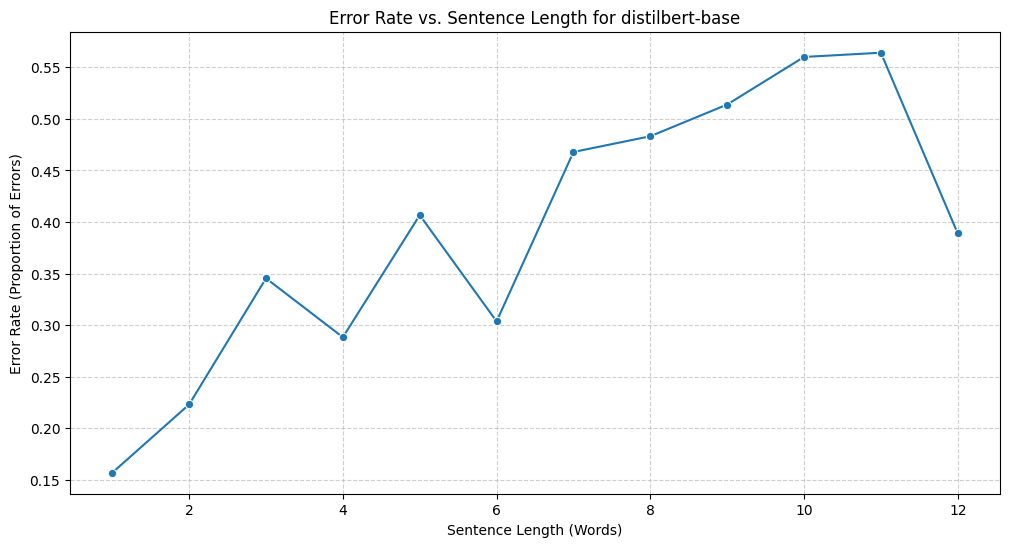

In [11]:
# --- SENTENCE LENGTH VS. ERROR RATE ANALYSIS ---

# 3. Analyze Sentence Length vs. Error Rate
# Calculate error rate per sentence length (word count)
results_df['Error'] = results_df['Correct'] == False

# Group by sentence length, calculate mean error rate
error_by_length = results_df.groupby('Sentence_Length')['Error'].agg(['count', 'mean']).reset_index()
error_by_length.columns = ['Sentence_Length', 'Total_Count', 'Error_Rate']

# Filter out very short/long sentences with low counts for stability
# We will consider lengths with at least 10 instances
error_by_length = error_by_length[error_by_length['Total_Count'] >= 10]

plt.figure(figsize=(12, 6))
sns.lineplot(x='Sentence_Length', y='Error_Rate', data=error_by_length, marker='o')
plt.title(f'Error Rate vs. Sentence Length for {model_name}')
plt.xlabel('Sentence Length (Words)')
plt.ylabel('Error Rate (Proportion of Errors)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [12]:
# --- TOP MISCLASSIFICATION PAIRS ---

# 4. Analyze Common Misclassification Pairs
print("\n--- Top Misclassification Pairs (True -> Predicted) ---")
# Filter only incorrect predictions
misclassifications = results_df[~results_df['Correct']]

# Group by true and predicted emotions
error_pairs = misclassifications.groupby(['True_Emotion', 'Pred_Emotion']).size().reset_index(name='Count')
top_5_pairs = error_pairs.sort_values(by='Count', ascending=False).head(5)

print(top_5_pairs.to_string(index=False))


--- Top Misclassification Pairs (True -> Predicted) ---
True_Emotion Pred_Emotion  Count
       anger      neutral     74
   happiness      neutral     61
     sadness      neutral     37
     neutral    happiness     29
       anger      sadness     25


In [13]:
# --- GRAVE VS. UNDERSTANDABLE ERROR CLASSIFICATION ---

# Define the function to classify error severity based on cross-valence distance.
# We consider errors between positive and negative valence as "Grave".
def classify_error_gravity(row):
    # Sets for valence classification
    POSITIVE_EMOTIONS = {'happiness'}
    # Surprise is often considered high-arousal and neutral/positive, but for simplicity
    # and to align with the core definition of "Grave" (positive vs. negative),
    # we treat surprise and neutral separately from the valence sets.
    NEGATIVE_EMOTIONS = {'anger', 'disgust', 'fear', 'sadness'}
    
    true_emotion = row['True_Emotion']
    pred_emotion = row['Pred_Emotion']
    
    # 1. Check for Positive -> Negative (Grave)
    if true_emotion in POSITIVE_EMOTIONS and pred_emotion in NEGATIVE_EMOTIONS:
        return 'Grave (Positive to Negative)'
    
    # 2. Check for Negative -> Positive (Grave)
    if true_emotion in NEGATIVE_EMOTIONS and pred_emotion in POSITIVE_EMOTIONS:
        return 'Grave (Negative to Positive)'

    # All other errors are considered 'Understandable'. This includes:
    # - Negative <-> Negative (e.g., Anger <-> Sadness)
    # - Any emotion <-> Neutral
    # - Any emotion <-> Surprise
    return 'Understandable'

# Apply the classification function to the existing misclassifications DataFrame
# Use .loc for safe assignment to avoid the SettingWithCopyWarning
misclassifications = misclassifications.copy()
misclassifications['Error_Type'] = misclassifications.apply(classify_error_gravity, axis=1)

print("\n--- Error Gravity Analysis ---")
# Calculate the distribution of error types
error_distribution = misclassifications['Error_Type'].value_counts(normalize=True).mul(100).round(2)
print(error_distribution.to_string())


--- Error Gravity Analysis ---
Error_Type
Understandable                  97.50
Grave (Negative to Positive)     2.27
Grave (Positive to Negative)     0.23


In [14]:
# Display a sample of the most serious (Grave) errors
print("\n--- Sample of Grave Errors (First 15) ---")
grave_errors_sample = misclassifications[misclassifications['Error_Type'].str.startswith('Grave')].head(15)
grave_errors_sample[['Sentence', 'True_Emotion', 'Pred_Emotion', 'Error_Type']]


--- Sample of Grave Errors (First 15) ---


,Sentence,True_Emotion,Pred_Emotion,Error_Type
63,for asking them to put their houses on the line.,fear,happiness,Grave (Negative to Positive)
264,It sounds like the owners are toast.,fear,happiness,Grave (Negative to Positive)
351,"God, I hope he likes something.",fear,happiness,Grave (Negative to Positive)
353,It's so bready.,disgust,happiness,Grave (Negative to Positive)
414,"I just trusted him to know what he was doing,",sadness,happiness,Grave (Negative to Positive)
701,Now he thinks it's funny.,anger,happiness,Grave (Negative to Positive)
704,It's a joke.,anger,happiness,Grave (Negative to Positive)
793,Yet you're happy to see all three family membe...,anger,happiness,Grave (Negative to Positive)
1039,I was kind of hoping to show up at the same time.,sadness,happiness,Grave (Negative to Positive)
1084,A night that started off with so much promise,sadness,happiness,Grave (Negative to Positive)
